# Master Dataset — Construcció i anàlisi de cobertura temporal

Aquest notebook construeix el dataset unificat del sistema agrivoltaic a partir de 12 fonts de dades de sensors independents.

**Flux de treball:**
1. Càrrega i renombrat dels CSV originals
2. Funcions helpers de neteja
3. Anàlisi de freqüència de lectura per sensor
4. Diagnosi de la columna duplicada a `precipitation_intensity`
5. Visualització de cobertura temporal
6. Construcció del Master Dataset amb interpolació

---

## Càrrega de dades i configuració d'entorn

Importa llibreries, defineix els directoris de treball i copia els CSV originals (amb noms llargs) a `./data/` amb noms curts normalitzats.

In [3]:
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from IPython.display import display
import shutil
import math

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 30)
pd.set_option('display.float_format', '{:.3f}'.format)
pd.set_option('display.max_colwidth', 60)

plt.rcParams['figure.figsize'] = (14, 4)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

NOTEBOOK_DIR = Path(os.getcwd())           
DATA_DIR     = NOTEBOOK_DIR/ 'data'
OUT_DIR      = NOTEBOOK_DIR / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

print(f'DATA_DIR  : {DATA_DIR}')
print(f'OUT_DIR   : {OUT_DIR}')


os.makedirs('./data', exist_ok=True)


files = {
    'AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv': 'air_temperature.csv',
    'AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv': 'par_radiation.csv',
    'PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv':              'pv_irradiance.csv',
    'PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv':   'pv_panel_temperature.csv',
    'Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv': 'precipitation_cumulative.csv',
    'Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv':              'precipitation_intensity.csv',
    'Precipitation_type_-data-2026-02-12 09_01_21.csv':                       'precipitation_type.csv',
    'SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv':           'soil_temperature.csv',
    'SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv':                   'soil_vwc.csv',
    'Tracking angles-data-as-joinbyfield-2026-02-12 14_24_26.csv':            'tracker_angles.csv',
    'Wind direction-data-2026-02-12 14_25_08.csv':                            'wind_direction.csv',
    'Wind speed-data-2026-02-12 09_05_40.csv':                                'wind_speed.csv',
}

for original, nou in files.items():
    src = f'../data/{original}'
    dst = f'./data/{nou}'
    shutil.copy2(src, dst)
    print(f'{original}\n   -> {nou}\n')

DATA_DIR  : \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\data
OUT_DIR   : \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\outputs
AIR_AIR Temperatures (ALL)-data-as-joinbyfield-2026-02-12 08_56_48.csv
   -> air_temperature.csv

AIR_ePAR (all parameters)-data-as-joinbyfield-2026-02-12 09_00_37.csv
   -> par_radiation.csv

PV_Irradiance-data-as-joinbyfield-2026-02-12 14_17_50.csv
   -> pv_irradiance.csv

PV_PV panel temperatures-data-as-joinbyfield-2026-02-12 14_18_22.csv
   -> pv_panel_temperature.csv

Precipitation (Total  Difference cumulative sum)-data-2026-02-12 14_23_21.csv
   -> precipitation_cumulative.csv

Precipitation-data-as-joinbyfield-2026-02-12 14_21_47.csv
   -> precipitation_intensity.csv

Precipitation_type_-data-2026-02-12 09_01_21.csv
   -> precipitation_type.csv

SOIL_Temperature-data-as-joinbyfield-2026-02-12 08_54_57.csv
   -> soil_temperature.csv

SOIL_VWC-data-as-joinbyfield-2026-02-12 08_57_18.csv
   -> soil_vwc.csv

Tracking

## Funcions helpers

- **`strip_unit`**: extreu el valor numèric de strings com `'28.8 °C'` o `'1024 W/m²'`. Gestiona tant `object` com el nou `StringDtype` de pandas.
- **`detect_sep_line`**: detecta si el CSV té una línia `sep=,` al principi (format Windows) i l'omet.
- **`load_csv`**: carrega qualsevol CSV del projecte de forma robusta (BOM UTF-8, línia sep=, normalitza la columna `Time`).
- **`strip_all_units`**: aplica `strip_unit` a totes les columnes no-temporals d'un DataFrame.

In [4]:
def strip_unit(series: pd.Series) -> pd.Series:
    """Extrae el valor numérico de strings tipo '28.8 °C', '1024 W/m²', '41.4 °'."""
    if series.dtype == object or pd.api.types.is_string_dtype(series):  # <-- añade is_string_dtype
        cleaned = series.astype(str).str.extract(r'([\-\d\.]+)', expand=False)
        return pd.to_numeric(cleaned, errors='coerce')
    return series


def detect_sep_line(filepath: Path) -> int:
    """Devuelve cuántas filas de cabecera extra saltar (0 o 1 si tiene 'sep=')."""
    with open(filepath, 'r', encoding='utf-8-sig') as f:
        first = f.readline().strip()
    return 1 if first.lower().startswith('sep=') else 0


def load_csv(filepath: Path, nrows: int = None) -> pd.DataFrame:
    """Carga un CSV manejando la línea sep= y el BOM UTF-8."""
    skip = detect_sep_line(filepath)
    df = pd.read_csv(
        filepath,
        skiprows=skip,
        encoding='utf-8-sig',
        nrows=nrows,
        low_memory=False
    )
    # Normalizar la columna temporal
    time_cols = [c for c in df.columns if c.strip().lower() == 'time']
    if time_cols:
        df = df.rename(columns={time_cols[0]: 'Time'})
        df['Time'] = pd.to_datetime(df['Time'], errors='coerce')
    return df


def strip_all_units(df: pd.DataFrame) -> pd.DataFrame:
    """Aplica strip_unit a todas las columnas no-Time."""
    df = df.copy()
    for col in df.columns:
        if col != 'Time':
            df[col] = strip_unit(df[col])
    return df

## Freqüència de lectura per sensor

Calcula la mediana dels intervals entre registres de cada sensor. Això és crític per a la construcció del Master Dataset: cada sensor té el seu propi ritme de mostreig (de 30s fins a 12h), i cal conèixer-lo per detectar huecos reals i definir el límit d'interpolació.

> **Nota:** `precipitation_type` s'ha exclòs del diccionari `SENSORS` per no tenir utilitat analítica directa tenint les altres variables de precipitació.

In [5]:
SENSORS = {
    'air_temperature':         'temp_aire',
    'par_radiation':           'rad_PAR',
    'pv_irradiance':           'irrad_PV',
    'pv_panel_temperature':    'temp_panel_PV',
    'precipitation_cumulative':'precip_acum',
    'precipitation_intensity': 'precip_intens',
    #'precipitation_type':      'tipo_precip', -> de momento quito Precipitation Type, no le veo la utilidad teniendo las otras variables de precipitation
    'soil_temperature':        'temp_suelo',
    'soil_vwc':                'vwx_suelo',
    'tracker_angles':          'tracker_angles',
    'wind_direction':          'dir_viento',
    'wind_speed':              'vel_viento',
}


for i, (key, label) in enumerate(SENSORS.items()):
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path)
    df = df.dropna(subset=['Time']).set_index('Time').sort_index()
    if df.empty:
        continue

    median = df.index.to_series().diff().dropna().median()
    print(f"{label:25s} - intervalo entre lecturas: {median}")

temp_aire                 - intervalo entre lecturas: 0 days 06:00:00
rad_PAR                   - intervalo entre lecturas: 0 days 06:00:00
irrad_PV                  - intervalo entre lecturas: 0 days 02:00:00
temp_panel_PV             - intervalo entre lecturas: 0 days 02:00:00
precip_acum               - intervalo entre lecturas: 0 days 00:00:30
precip_intens             - intervalo entre lecturas: 0 days 00:00:30
temp_suelo                - intervalo entre lecturas: 0 days 06:00:00
vwx_suelo                 - intervalo entre lecturas: 0 days 06:00:00
tracker_angles            - intervalo entre lecturas: 0 days 06:00:00
dir_viento                - intervalo entre lecturas: 0 days 12:00:00
vel_viento                - intervalo entre lecturas: 0 days 06:00:00


In [6]:
df_pt = load_csv(DATA_DIR / 'precipitation_type.csv')
print(df_pt.dtypes)
print(df_pt.head(5))
print(df_pt.iloc[:, 1].value_counts().head(10))

for key, label in SENSORS.items():
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path)
    df = strip_all_units(df)
    df = df.dropna(subset=['Time']).set_index('Time').sort_index()
    if df.empty:
        continue

    data_cols = [c for c in df.columns]
    # Filas donde TODAS las columnas son null
    all_null = df[data_cols].isna().all(axis=1)
    
    first_real = df.index[~all_null][0]  if (~all_null).any() else None
    last_real  = df.index[~all_null][-1] if (~all_null).any() else None
    n_leading  = all_null[:first_real].sum() if first_real else len(df)
    n_trailing = all_null[last_real:].sum()  if last_real  else len(df)

    
    print(f"{label:20s} | inicio CSV: {df.index[0].date()} → primer dato real: {first_real.date() if first_real else '—'} ({n_leading} filas vacías al inicio)")
    print(f"{'':20s} | fin CSV:    {df.index[-1].date()} → último dato real:  {last_real.date() if last_real else '—'} ({n_trailing} filas vacías al final)")
    print()

Time                  datetime64[us]
Precipitation Type               str
dtype: object
                 Time Precipitation Type
0 2025-06-16 11:55:30   No precipitation
1 2025-06-18 15:11:00   No precipitation
2 2025-06-18 15:11:30   No precipitation
3 2025-06-18 15:12:00   No precipitation
4 2025-06-18 15:12:30   No precipitation
Precipitation Type
No precipitation               571201
Liquid precipitation (rain)     33347
Solid precipitation (snow)        371
sleet                              91
Name: count, dtype: int64
temp_aire            | inicio CSV: 2025-02-12 → primer dato real: 2025-06-16 (496 filas vacías al inicio)
                     | fin CSV:    2026-02-12 → último dato real:  2026-02-12 (0 filas vacías al final)

rad_PAR              | inicio CSV: 2025-02-12 → primer dato real: 2025-06-18 (505 filas vacías al inicio)
                     | fin CSV:    2026-02-12 → último dato real:  2026-02-12 (0 filas vacías al final)

irrad_PV             | inicio CSV: 2025-05-12 →

## Diagnosi de `precipitation_intensity`

El CSV de precipitació té dues columnes amb el mateix nom (`Precipitation Intensity`), que pandas renombra automàticament com `.1`. S'analitza si contenen informació diferent o complementària.

In [7]:
prep_int = DATA_DIR / 'precipitation_intensity.csv'

df = load_csv(prep_int).dropna(subset=['Time']).set_index('Time').sort_index()
print(df.columns.tolist())
print(df.shape)
df.head()

a = df['Precipitation Intensity']
b = df['Precipitation Intensity.1']

# Casos
both_null   = a.isna() & b.isna()
only_a      = a.notna() & b.isna()
only_b      = a.isna() & b.notna()
both_diff   = a.notna() & b.notna() & (a != b)
both_equal  = a.notna() & b.notna() & (a == b)

print(f"Ambas null:          {both_null.sum():>8,}")
print(f"Solo columna A:      {only_a.sum():>8,}")
print(f"Solo columna B:      {only_b.sum():>8,}")
print(f"Ambas, valores ≠:    {both_diff.sum():>8,}")
print(f"Ambas, valores =:    {both_equal.sum():>8,}")
print(f"{'─'*30}")
print(f"Total filas:         {len(df):>8,}")

['Precipitation Intensity', 'Precipitation Intensity.1']
(605682, 2)
Ambas null:                 0
Solo columna A:       427,198
Solo columna B:       141,452
Ambas, valores ≠:           0
Ambas, valores =:      37,032
──────────────────────────────
Total filas:          605,682


### Fusió de les columnes duplicades

Com que les dues columnes mai difereixen quan ambdues tenen valor (`both_diff = 0`), es fusionen amb `combine_first`: agafa el valor de la columna A i, on A és null, usa B. El resultat és una sola columna sense nulls. El CSV es sobreescriu.

In [8]:
df['Precipitation Intensity'] = a.combine_first(b)
df = df.drop(columns=['Precipitation Intensity.1'])

print(f"Nulos restantes: {df['Precipitation Intensity'].isna().sum():,}")
print(df.shape)

df.to_csv(prep_int, index=True)
print(f"Guardado en {prep_int}")

Nulos restantes: 0
(605682, 1)
Guardado en \\wsl.localhost\Ubuntu\home\pablo_laptop\GIA\PIA\PIA_lab\sprint3\data\precipitation_intensity.csv


## Cobertura temporal per sensor

Visualització tipus Gantt: cada sensor és una línia horitzontal des del seu **primer registre real** fins a l'últim. Els huecos (salts > 2× l'interval típic del sensor) es marquen en vermell.

**Important:** s'exclouen les files on totes les columnes de dades són null, que apareixien al principi de molts CSV abans que el sensor comencés a registrar.

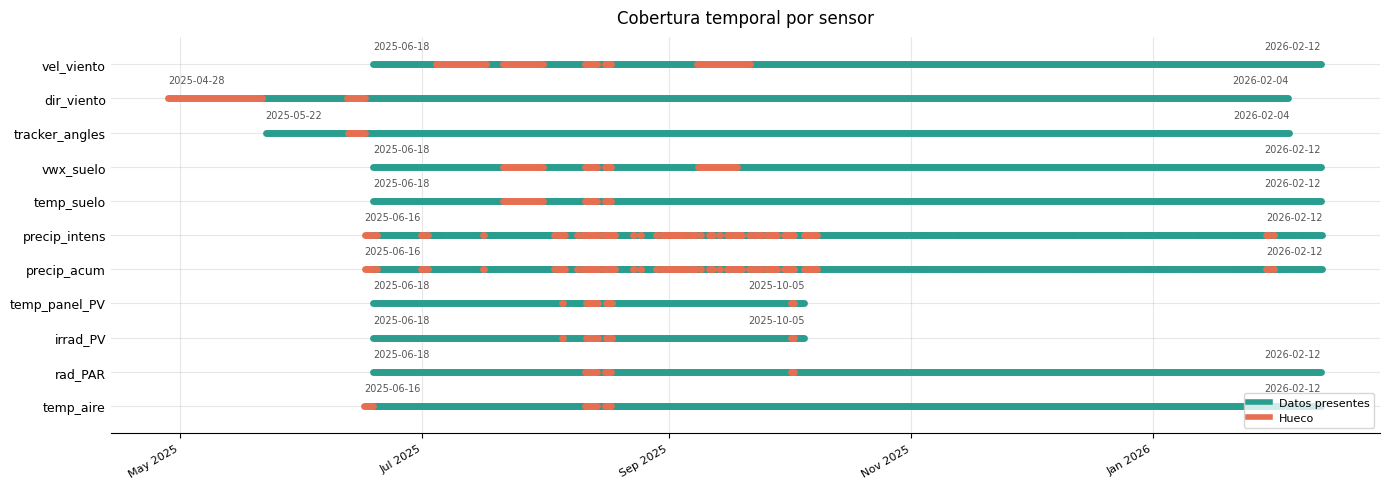

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))

labels_plotted = []

for i, (key, label) in enumerate(SENSORS.items()):
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path).dropna(subset=['Time']).set_index('Time').sort_index()
    if df.empty:
        continue

    # ── CAMBIO 1: recortar filas donde todos los valores son null ──
    all_null = df.isna().all(axis=1)
    df = df[~all_null]
    if df.empty:
        continue

    first_real = df.index[0]
    last_real  = df.index[-1]

    median    = df.index.to_series().diff().dropna().median()
    threshold = 2 * median
    diffs     = df.index.to_series().diff()
    gap_mask  = diffs > threshold
    segment_id = gap_mask.cumsum()

    for seg, group in df.groupby(segment_id):
        ax.plot([group.index[0], group.index[-1]], [i, i],
                lw=5, solid_capstyle='round', color='#2A9D8F', zorder=2)

    for gap_end in df.index[gap_mask]:
        gap_start = df.index[df.index.get_loc(gap_end) - 1]
        ax.plot([gap_start, gap_end], [i, i],
                lw=5, solid_capstyle='round', color='#E76F51', zorder=3)

    # ── CAMBIO 2: fechas usando first_real / last_real ──
    ax.text(first_real, i + 0.38, first_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='left', va='bottom')
    ax.text(last_real,  i + 0.38, last_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='right', va='bottom')

    labels_plotted.append(label)

ax.set_yticks(range(len(labels_plotted)))
ax.set_yticklabels(labels_plotted, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_title('Cobertura temporal por sensor', fontsize=12, pad=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', length=0)
ax.set_ylim(-0.8, len(labels_plotted) - 0.2)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='#2A9D8F', lw=4, label='Datos presentes'),
    Line2D([0], [0], color='#E76F51', lw=4, label='Hueco'),
], fontsize=8, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cobertura_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

## Definició de la política d'interpolació

El Master Dataset tindrà freqüència base de **30 segons** (el sensor més ràpid). Els sensors amb intervals més grans necessiten interpolació per omplir els buits:

| Política | Sensors | Justificació |
|---|---|---|
| `linear` | temperatures aire, panell PV, sòl | Variables que canvien gradualment; la interpolació lineal és físicament plausible |
| `ffill` | resta de sensors | Manté l'últim valor conegut sense inventar transicions |
| `none` | — (precipitation_type eliminat) | Variables categòriques: no té sentit interpolar |

**Límit d'interpolació:** màxim 2× l'interval típic del sensor. Més enllà d'això és un forat real i es deixa com `NaN`.

In [14]:
SENSOR_INFO = {
    'air_temperature':          {'interval_s': 6*3600,  'interp': 'linear'},
    'par_radiation':            {'interval_s': 6*3600,  'interp': 'pchip'},  
    'pv_irradiance':            {'interval_s': 2*3600,  'interp': 'pchip'},  
    'pv_panel_temperature':     {'interval_s': 2*3600,  'interp': 'linear'},
    'precipitation_cumulative': {'interval_s': 30,      'interp': 'ffill'},
    'precipitation_intensity':  {'interval_s': 30,      'interp': 'none'},
    'precipitation_type':       {'interval_s': 30,      'interp': 'none'},
    'soil_temperature':         {'interval_s': 6*3600,  'interp': 'linear'},
    'soil_vwc':                 {'interval_s': 6*3600,  'interp': 'linear'}, 
    'tracker_angles':           {'interval_s': 6*3600,  'interp': 'linear'}, # PROVISIONAL
    'wind_direction':           {'interval_s': 12*3600, 'interp': 'linear'}, 
    'wind_speed':               {'interval_s': 6*3600,  'interp': 'linear'}, 
}

## Construcció del Master Dataset

Join de tots els sensors sobre un índex temporal comú de 30 segons:
1. Es calcula el rang global usant el **primer i últim registre real** de cada sensor (excloent files tot-null)
2. Cada sensor es reindexat a l'índex base i s'aplica la seva política d'interpolació
3. Les columnes es prefixen amb el nom del sensor (`sensor__columna`) per evitar col·lisions de noms
4. El resultat es desa a `outputs/master_dataset.csv`

In [16]:
BASE_FREQ   = '30s'
BASE_FREQ_S = 30 

# Índice base: primer y último dato REAL de cada sensor (sin filas todo-null)
all_starts, all_ends = [], []
for key in SENSOR_INFO:
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue
    df = load_csv(path).dropna(subset=['Time']).set_index('Time').sort_index()
    all_null = df.isna().all(axis=1)
    df = df[~all_null]
    if df.empty:
        continue
    all_starts.append(df.index[0])
    all_ends.append(df.index[-1])

master_index = pd.date_range(min(all_starts), max(all_ends), freq=BASE_FREQ)
master = pd.DataFrame(index=master_index)
master.index.name = 'Time'

# Merge de cada sensor
for key, info in SENSOR_INFO.items():
    path = DATA_DIR / f'{key}.csv'
    if not path.exists():
        continue

    df = load_csv(path)
    df = strip_all_units(df)
    df = df.dropna(subset=['Time']).set_index('Time').sort_index()
    df = df[~df.index.duplicated(keep='first')]

    # Recortar filas todo-null antes de reindexar
    all_null = df.isna().all(axis=1)
    df = df[~all_null]
    if df.empty:
        continue

    limit_steps = int((2 * info['interval_s']) / BASE_FREQ_S)
    df = df.reindex(master.index)

    for col in df.columns:
        df[col] = strip_unit(df[col])
        
        # Lógica de interpolación aplicada según SENSOR_INFO
        if info['interp'] == 'linear':
            df[col] = df[col].interpolate(method='time', limit=limit_steps,
                                          limit_direction='forward')
        elif info['interp'] == 'ffill':
            df[col] = df[col].ffill(limit=limit_steps)
        elif info['interp'] == 'pchip':
            df[col] = df[col].interpolate(method='pchip', limit=limit_steps).clip(lower=0)

    master = master.join(df.add_prefix(f'{key}__'), how='left')

print(f"Shape master: {master.shape}")
print(f"Rango: {master.index[0]} → {master.index[-1]}")
print(f"\nNulos por columna:")
print(master.isna().sum().to_string())

master.to_csv(OUT_DIR / 'master_dataset.csv', index=True)
print(f"\nGuardado en {OUT_DIR / 'master_dataset.csv'}")

Shape master: (836681, 90)
Rango: 2025-04-28 02:00:00 → 2026-02-12 14:20:00

Nulos por columna:
air_temperature__R1d40_Z8AI.air.T.degC                                 258475
air_temperature__WS100.Air.TempAct.degC                                156235
air_temperature__WS100.Air.TempAvg.degC                                156235
air_temperature__WS100.Air.TempMax.degC                                156235
air_temperature__WS100.Air.TempMin.degC                                156235
air_temperature__WS100.Heating.Temperature.degC                        157676
air_temperature__R1d40_Z8AI.air.T.degC.1                               258475
air_temperature__S1d10_Z8AI.air.T__center.degC                         159117
air_temperature__S1d10_Z8AI.air.T__east.degC                           159117
air_temperature__S1d10_Z8AI.air.T__west.degC                           159117
air_temperature__S2d30_Z8AI.air.T__east.degC                           159117
air_temperature__S2d30_Z8AI.air.T__west.degC  

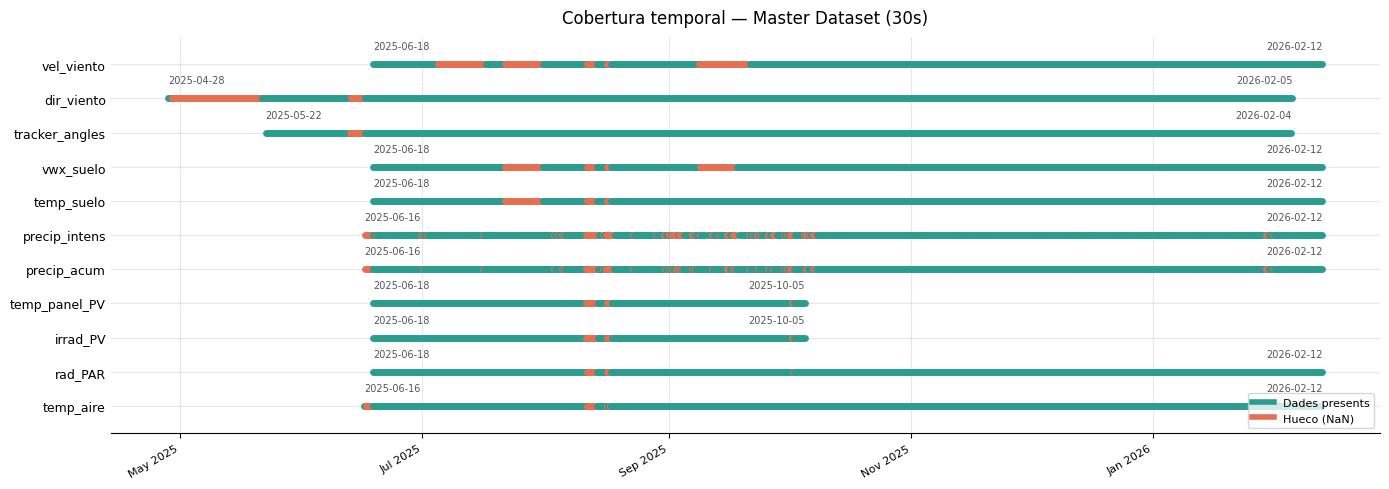

In [17]:
fig, ax = plt.subplots(figsize=(14, 5))

labels_plotted = []

master = pd.read_csv(OUT_DIR / 'master_dataset.csv', index_col='Time', parse_dates=True)

for i, (key, label) in enumerate(SENSORS.items()):
    # Columnes d'aquest sensor al master
    cols = [c for c in master.columns if c.startswith(f'{key}__')]
    if not cols:
        continue

    # Màscara: fila amb almenys un valor no-null en aquest sensor
    has_data = master[cols].notna().any(axis=1)
    if not has_data.any():
        continue

    first_real = master.index[has_data][0]
    last_real  = master.index[has_data][-1]

    # Huecos: blocs consecutius sense dades dins del rang actiu del sensor
    sensor_range = has_data.loc[first_real:last_real]
    segment_id   = (sensor_range != sensor_range.shift()).cumsum()

    for seg_val, group in sensor_range.groupby(segment_id):
        color = '#2A9D8F' if group.iloc[0] else '#E76F51'
        ax.plot([group.index[0], group.index[-1]], [i, i],
                lw=5, solid_capstyle='round', color=color, zorder=2)

    ax.text(first_real, i + 0.38, first_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='left', va='bottom')
    ax.text(last_real,  i + 0.38, last_real.strftime('%Y-%m-%d'),
            fontsize=7, color='#555', ha='right', va='bottom')

    labels_plotted.append(label)

ax.set_yticks(range(len(labels_plotted)))
ax.set_yticklabels(labels_plotted, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
ax.set_title('Cobertura temporal — Master Dataset (30s)', fontsize=12, pad=10)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.grid(axis='x', alpha=0.3)
ax.tick_params(axis='y', length=0)
ax.set_ylim(-0.8, len(labels_plotted) - 0.2)

from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([0], [0], color='#2A9D8F', lw=4, label='Dades presents'),
    Line2D([0], [0], color='#E76F51', lw=4, label='Hueco (NaN)'),
], fontsize=8, loc='lower right', framealpha=0.8)

plt.tight_layout()
plt.savefig(OUT_DIR / 'cobertura_master.png', dpi=150, bbox_inches='tight')
plt.show()